Hi, Hello, World!


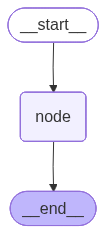

In [23]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict
from IPython.display import Image


class agentState(TypedDict):
    message: str


def node_function(state: agentState) -> agentState:
    state["message"] += " Hello, World!"
    print(state["message"])
    return state


graph = StateGraph(agentState)
graph.add_node("node", node_function)
graph.add_edge(START, "node")
graph.add_edge("node", END)
app = graph.compile()
app.invoke({"message": "Hi,"})
Image(app.get_graph().draw_mermaid_png())

Hi, I'm First Node!
Hi, I'm First Node! I'm router Node!
Hi, I'm First Node! I'm Node B!


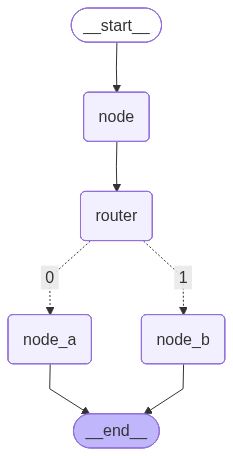

In [22]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict
from IPython.display import Image
from random import randint


class agentState(TypedDict):
    message: str


def node_function(state: agentState) -> agentState:
    state["message"] += " I'm First Node!"
    print(state["message"])
    return state


def router_node_function(state: agentState) -> agentState:
    state["message"] += " I'm router Node!"
    a = randint(0, 1)
    print(state["message"])
    if a == 0:
        state["message"] += " Taking path 0!"
    else:
        state["message"] += " Taking path 1!"
    return a


def node_a_function(state: agentState) -> agentState:
    state["message"] += " I'm Node A!"
    print(state["message"])
    return state


def node_b_function(state: agentState) -> agentState:
    state["message"] += " I'm Node B!"
    print(state["message"])
    return state


graph = StateGraph(agentState)
graph.add_node("node", node_function)
graph.add_node("router", lambda state: state)
graph.add_node("node_a", node_a_function)
graph.add_node("node_b", node_b_function)
graph.add_edge(START, "node")
graph.add_edge("node", "router")
graph.add_conditional_edges("router", router_node_function, {0: "node_a", 1: "node_b"})
graph.add_edge("node_a", END)
graph.add_edge("node_b", END)
app = graph.compile()
app.invoke({"message": "Hi,"})
Image(app.get_graph().draw_mermaid_png())